# Conv+GRU on raw EMG waveforms — training

Raw-waveform counterpart of `allPhonemesRnn.ipynb` / `wordsRnn.ipynb` (see `../_notes/plan-raw-waveform-baseline.md`).
Loading, per-channel z-scoring, labels, `Indices`, the 6/4 split, `BaseDataset`, `DataLoader` config, and the
max-over-epochs test-accuracy protocol are copied from those notebooks. The one change is that the sliding-window covariance loop is removed:
the z-scored `(22, 7500)` trial goes straight into the split, and the model windows it internally on the same 46-step grid.

Runs 4 configs × 10 seeds × 500 epochs (the SPD-RNN notebooks use 150; this model is still underfit at 150) and writes per-seed, per-epoch test accuracies to `results.json`. No model weights are saved.

In [1]:
import sys, json, time
sys.path.insert(0, "..")  # repo root, for spdLearning

import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

from spdLearning import trainTest  # single-optimizer version; works with plain Adam
import convGru
import matplotlib.pyplot as plt

In [2]:
class BaseDataset(Dataset):
    def __init__(self, data, labels):
        self.data = data
        self.labels = labels

    def __getitem__(self, index):
        return self.data[index].astype('float32'), self.labels[index]

    def __len__(self):
        return len(self.data)

In [3]:
dev = "cuda:0" 
device = torch.device(dev)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
print(torch.cuda.get_device_name(0), torch.__version__)

NVIDIA GeForce RTX 3090 2.14.0+cu130


In [4]:
subjectNumber = 1
subject = "Subject" + str(subjectNumber)
trialsPerClass = 10
numberChannels = 22
windowLength = 7500
numberEpochs = 500
seeds = list(range(10))

# (task, folder, number of classes)
tasks = [("allPhonemes", "Phoneme", 38), ("allWords", "Words", 36)]
articulationManners = ["Voiced", "Unvoiced"]

In [5]:
def loadRawSplit(folder, articulationManner, numberClasses):
    """Cells 8-9 of allPhonemesRnn.ipynb / wordsRnn.ipynb, minus the covariance loop."""
    numberTrials = numberClasses * trialsPerClass
    DATA = np.load("Experiment1/" + folder + "/" + articulationManner + subject + ".npy")

    mean = np.mean(DATA, axis = -1)
    std = np.std(DATA, axis = -1)
    DATA = (DATA - mean[..., np.newaxis])/(std[..., np.newaxis] + 1e-5)

    labelsByClass = np.array([[i] * trialsPerClass for i in range(numberClasses)]).reshape(numberTrials)

    Indices =  {}
    for i in range(numberClasses):
        Indices[i] = []
    for i in range(len(labelsByClass)):
        Indices[labelsByClass[i]].append(i)

    trialsByClass = np.zeros((numberClasses, trialsPerClass, numberChannels, windowLength))
    for i in range(numberClasses):
        for j in range(trialsPerClass):
            trialsByClass[i, j] = DATA[Indices[i][j]]

    trainFeatures = np.zeros((numberClasses * 6, numberChannels, windowLength))
    trainLabels = np.zeros((numberClasses * 6))
    count = 0
    for i in range(numberClasses):
        trainFeatures[count:count + 3] = trialsByClass[i, :3]
        trainFeatures[count + 3:count + 6] = trialsByClass[i, 5:8]
        trainLabels[count:count + 6] = [i] * 6
        count += 6

    testFeatures = np.zeros((numberClasses * 4, numberChannels, windowLength))
    testLabels = np.zeros((numberClasses * 4))
    count = 0
    for i in range(numberClasses):
        testFeatures[count:count + 2] = trialsByClass[i, 3:5]
        testFeatures[count + 2:count + 4] = trialsByClass[i, 8:10]
        testLabels[count:count + 4] = [i] * 4
        count += 4
    return trainFeatures, trainLabels, testFeatures, testLabels

In [6]:
# Everything reported below is also appended to progress.log, so it can be followed with `tail -f` while the notebook runs.
open("progress.log", "w").close()
def report(line):
    print(line)
    with open("progress.log", "a") as f:
        f.write(line + "\n")


In [7]:
results = {}
for task, folder, numberClasses in tasks:
    for articulationManner in articulationManners:
        trainFeatures, trainLabels, testFeatures, testLabels = loadRawSplit(folder, articulationManner, numberClasses)
        trainDataset = BaseDataset(trainFeatures, trainLabels)
        testDataset = BaseDataset(testFeatures, testLabels)
        configName = task + "_" + articulationManner
        report(f"=== {configName}: train {trainFeatures.shape}, test {testFeatures.shape}")

        seedRuns = []
        for seed in seeds:
            torch.manual_seed(seed)
            np.random.seed(seed)
            torch.cuda.manual_seed_all(seed)
            trainDataloader = DataLoader(trainDataset, batch_size = 32, shuffle = True)
            testDataloader = DataLoader(testDataset, batch_size = 32, shuffle = False)

            model = convGru.convGruNet(numberClasses).to(device)
            numParams = sum(p.numel() for p in model.parameters() if p.requires_grad)
            lossFunction = nn.CrossEntropyLoss()
            optimizer = optim.Adam(model.parameters(), lr = 0.001, weight_decay = 1e-3)

            startTime = time.time()
            maxValue = 0
            bestEpoch = 0
            testAccuracies, trainAccuracies = [], []
            for epoch in range(numberEpochs):
                trainLoss, trainAccuracy = trainTest.trainOperation(model, device, trainDataloader, optimizer, lossFunction)
                testLoss, testAccuracy = trainTest.testOperation(model, device, testDataloader, lossFunction)
                if maxValue < testAccuracy:
                    maxValue = testAccuracy
                    bestEpoch = epoch + 1
                trainAccuracies.append(trainAccuracy / 100)
                testAccuracies.append(testAccuracy / 100)
                if (epoch + 1) % 10 == 0:
                    report(f"  seed {seed} epoch {epoch + 1:>3}/{numberEpochs}: train acc {trainAccuracy / 100:.3f}, test acc {testAccuracy / 100:.3f}, "
                           f"train loss {trainLoss:.4f}, test loss {testLoss:.4f}")
            report(f"seed {seed}: max-over-epochs test acc {maxValue / 100:.3f} at epoch {bestEpoch}, final-epoch test acc {testAccuracy / 100:.3f}, "
                  f"final train acc {trainAccuracy / 100:.3f}, params {numParams}, {time.time() - startTime:.0f}s")
            seedRuns.append({"seed": seed, "maxTestAccuracy": maxValue / 100, "bestEpoch": bestEpoch, "finalTestAccuracy": testAccuracy / 100,
                             "testAccuracyByEpoch": testAccuracies, "trainAccuracyByEpoch": trainAccuracies})

        maxTestAccuracies = np.array([r["maxTestAccuracy"] for r in seedRuns])
        finalTestAccuracies = np.array([r["finalTestAccuracy"] for r in seedRuns])
        bestEpochs = np.array([r["bestEpoch"] for r in seedRuns])
        report(f"--> {configName}: max-over-epochs {maxTestAccuracies.mean():.3f} ± {maxTestAccuracies.std():.3f}, "
              f"final epoch {finalTestAccuracies.mean():.3f} ± {finalTestAccuracies.std():.3f}, "
               f"best epoch median {np.median(bestEpochs):.0f} (range {bestEpochs.min()}-{bestEpochs.max()})")
        results[configName] = {"task": task, "articulationManner": articulationManner, "numberClasses": numberClasses,
                               "numberTestSamples": len(testLabels), "numParams": numParams, "runs": seedRuns}

=== allPhonemes_Voiced: train (228, 22, 7500), test (152, 22, 7500)


  seed 0 epoch  10/500: train acc 0.057, test acc 0.039, train loss 0.1274, test loss 0.1190


  seed 0 epoch  20/500: train acc 0.026, test acc 0.059, train loss 0.1253, test loss 0.1175


  seed 0 epoch  30/500: train acc 0.079, test acc 0.079, train loss 0.1223, test loss 0.1141


  seed 0 epoch  40/500: train acc 0.114, test acc 0.112, train loss 0.1089, test loss 0.1027


...

  seed 9 epoch 460/500: train acc 0.995, test acc 0.597, train loss 0.0022, test loss 0.0499


  seed 9 epoch 470/500: train acc 0.991, test acc 0.667, train loss 0.0047, test loss 0.0389


  seed 9 epoch 480/500: train acc 1.000, test acc 0.674, train loss 0.0019, test loss 0.0412


  seed 9 epoch 490/500: train acc 1.000, test acc 0.653, train loss 0.0016, test loss 0.0430


  seed 9 epoch 500/500: train acc 1.000, test acc 0.660, train loss 0.0017, test loss 0.0447
seed 9: max-over-epochs test acc 0.688 at epoch 117, final-epoch test acc 0.660, final train acc 1.000, params 44924, 53s
--> allWords_Unvoiced: max-over-epochs 0.678 ± 0.036, final epoch 0.626 ± 0.036, best epoch median 343 (range 117-480)


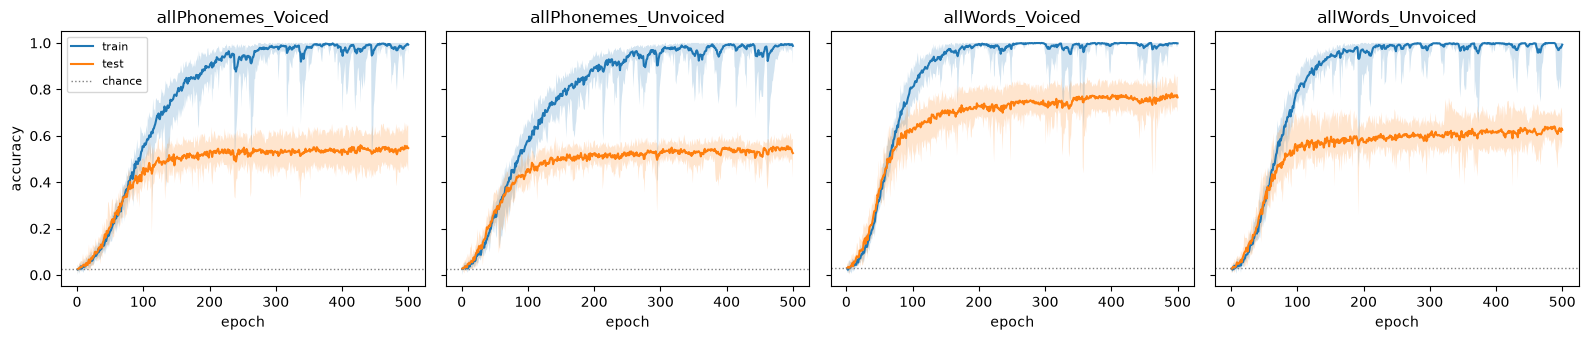

In [8]:
# Train / test accuracy over epochs per config: mean over the 10 seeds, shaded min-max
fig, axes = plt.subplots(1, len(results), figsize = (16, 3.5), sharey = True)
for ax, (configName, config) in zip(axes, results.items()):
    epochs = np.arange(1, numberEpochs + 1)
    for key, label in [("trainAccuracyByEpoch", "train"), ("testAccuracyByEpoch", "test")]:
        accuracyBySeed = np.array([r[key] for r in config["runs"]])
        ax.plot(epochs, accuracyBySeed.mean(0), label = label)
        ax.fill_between(epochs, accuracyBySeed.min(0), accuracyBySeed.max(0), alpha = 0.2)
    ax.axhline(1 / config["numberClasses"], color = "gray", ls = ":", lw = 1, label = "chance")
    ax.set_title(configName)
    ax.set_xlabel("epoch")
axes[0].set_ylabel("accuracy")
axes[0].legend(fontsize = 8)
plt.tight_layout()
plt.show()

In [9]:
with open("results.json", "w") as f:
    json.dump({"subjectNumber": subjectNumber, "numberEpochs": numberEpochs, "seeds": seeds, "configs": results}, f)
print("wrote results.json")

wrote results.json
